Getting Started with Images
This notebook will help you take your first steps in learning Image Processing and Computer Vision using OpenCV. You will learn some important lessons using some simple examples. In this notebook, you will learn the following:

Reading an image
Check image attributes like datatype and shape
Matrix representation of an image in Numpy
Color Images and splitting/merging image channels
Displaying images using matplotlib
Saving images

Import libraries

In [2]:
import cv2 #opencv lib
import numpy as np

In [3]:
cv2.__version__

'5.0.0'

In [4]:
img=np.ones((3,3,3)) #3d array of 3*3 and 3 channels(blocks)
img

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]])

In [5]:
img.shape #the shape of image

(3, 3, 3)

In [6]:
cv2.add(img,20) #add 20 to all the pixels of the image

array([[[21., 21., 21.],
        [21., 21., 21.],
        [21., 21., 21.]],

       [[21., 21., 21.],
        [21., 21., 21.],
        [21., 21., 21.]],

       [[21., 21., 21.],
        [21., 21., 21.],
        [21., 21., 21.]]])

In [7]:
import os # for interacting with underlying os of the system
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image #image tool from Ipython library where I means Interactive 
%matplotlib inline 
#the above  command is used to display the image in notebook not in another window


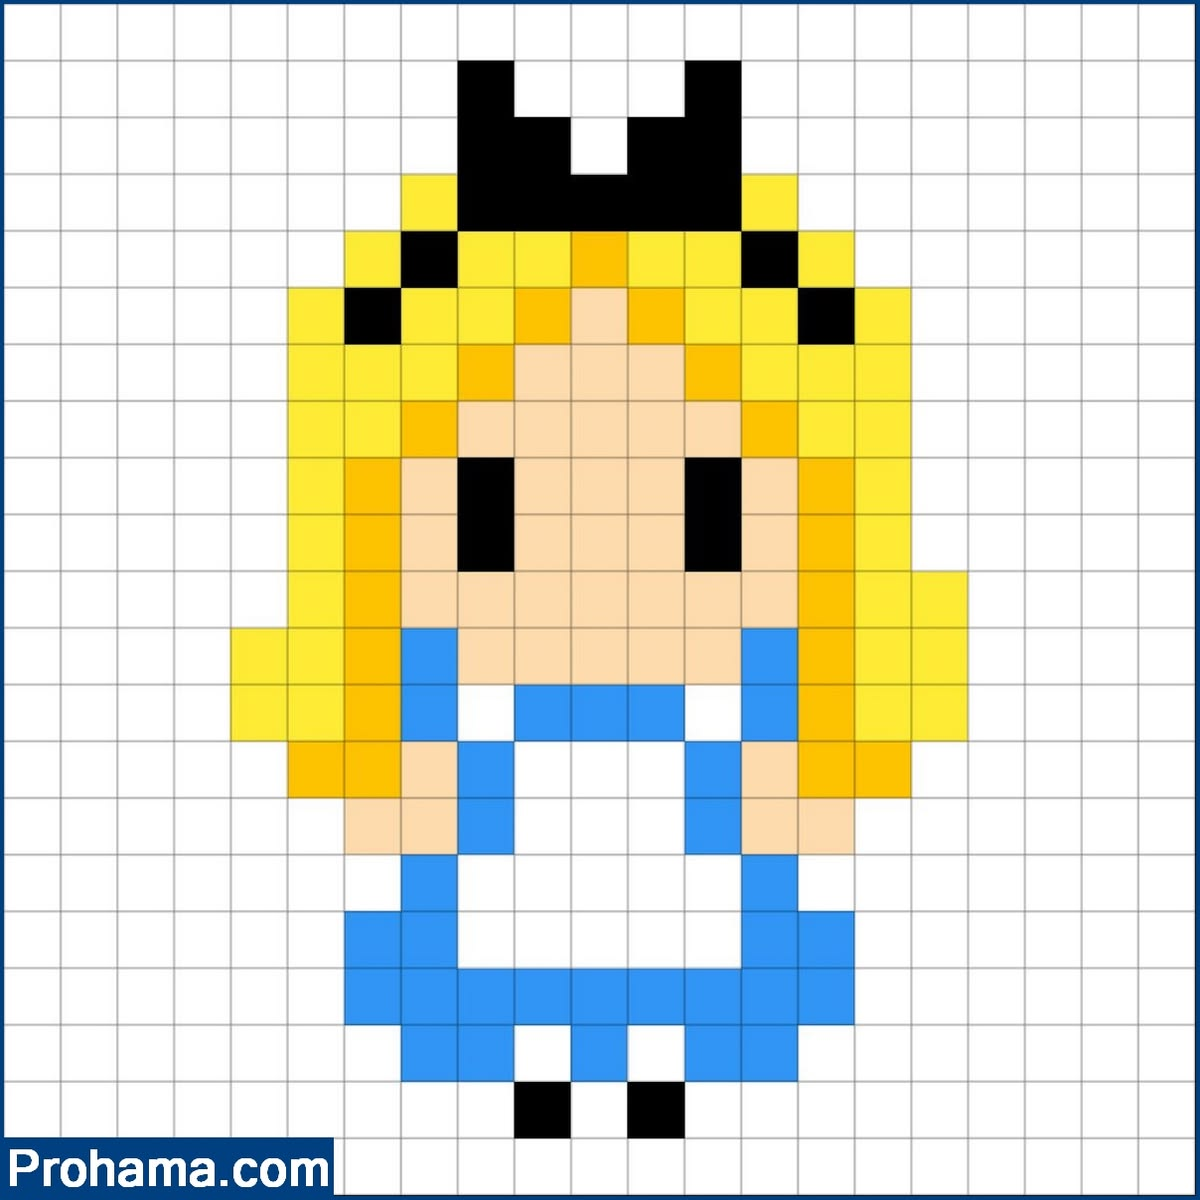

In [9]:
Image(filename="S:\\CV-JOURNAL\\ComputerVision-Journal\\OpenCVBootcamp\\alice21.jpg") 

In [10]:
#Reading image in grayscale 
alice_gray=cv2.imread("S:\\CV-JOURNAL\\ComputerVision-Journal\\OpenCVBootcamp\\alice21.jpg",0)

# Print the image data (pixel values), element of a 2D numpy array.
# Each pixel value is 8-bits [0,255]
print(alice_gray)

[[51 48 54 ... 54 56 55]
 [53 49 51 ... 56 55 51]
 [49 52 54 ... 54 50 53]
 ...
 [52 52 52 ... 52 52 52]
 [52 52 52 ... 54 51 48]
 [52 52 52 ... 56 51 53]]


In [ ]:
# print the size  of image
print("Image size (H, W) is:", alice_gray.shape)

# print data-type of image
#unsigned integer type stores from 0 to 255
print("Data type of image is:", alice_gray.dtype)

Image size (H, W) is: (1200, 1200)
Data type of image is: uint8


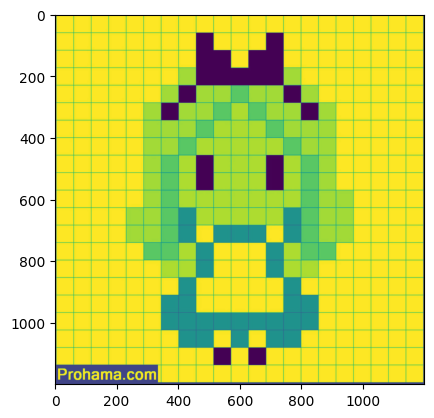

In [12]:
#Display image using matplotlib
plt.imshow(alice_gray)

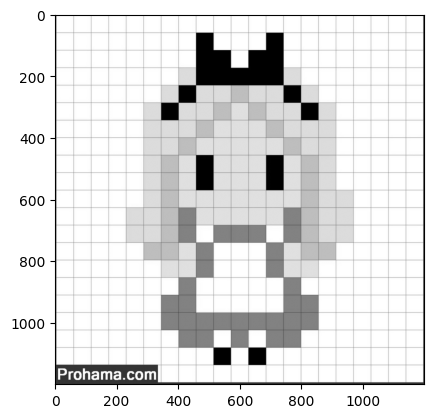

In [13]:
# Set color map to gray scale for proper rendering.
plt.imshow(alice_gray,cmap="gray")

Working with color images

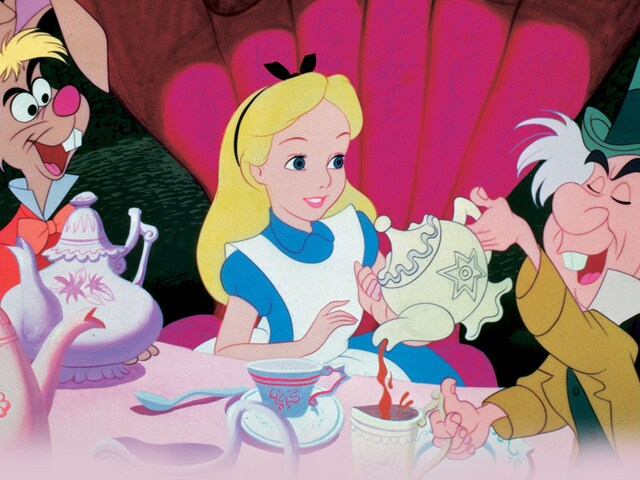

In [ ]:
Image("alice_wonderland.jpeg") #displaying image

In [15]:
#Read in image
alicecolor=cv2.imread("alice_wonderland.jpeg",1) #color image
# print the size of the color image
print("Color image size (H, W) is:", alicecolor.shape)
# print data-type of the color image
print("Data type of color image is:", alicecolor.dtype)

Color image size (H, W) is: (480, 640, 3)
Data type of color image is: uint8


Display image

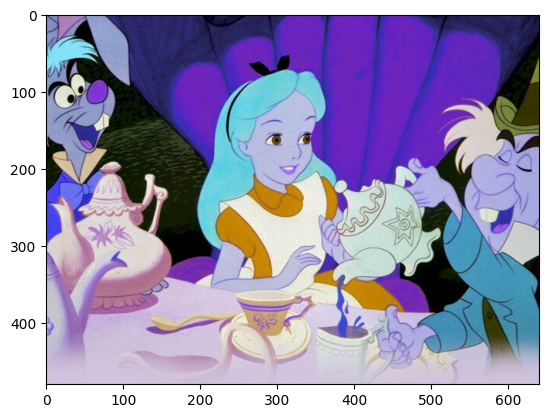

In [16]:
plt.imshow(alicecolor)

The color displayed above is different from the actual image. This is because matplotlib expects the image in RGB format whereas OpenCV stores images in BGR format. Thus, for correct display, we need to reverse the channels of the image. We will discuss about the channels in the sections below.

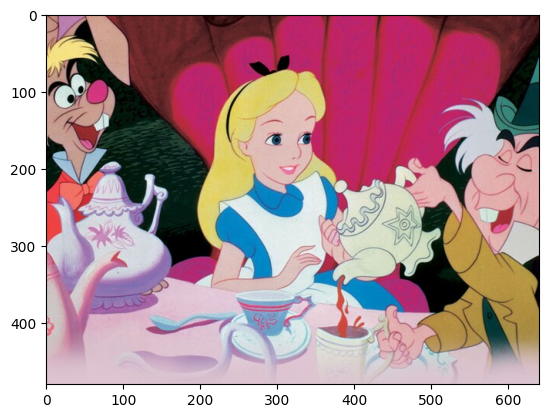

In [17]:
alice_reverse=alicecolor[:,:,::-1]
plt.imshow(alice_reverse)

Splitting and Merging Color Channels

cv2.split() Divides a multi-channel array into several single-channel arrays.

cv2.merge() Merges several arrays to make a single multi-channel array. All the input matrices must have the same size.

Text(0.5, 1.0, 'Merged image')

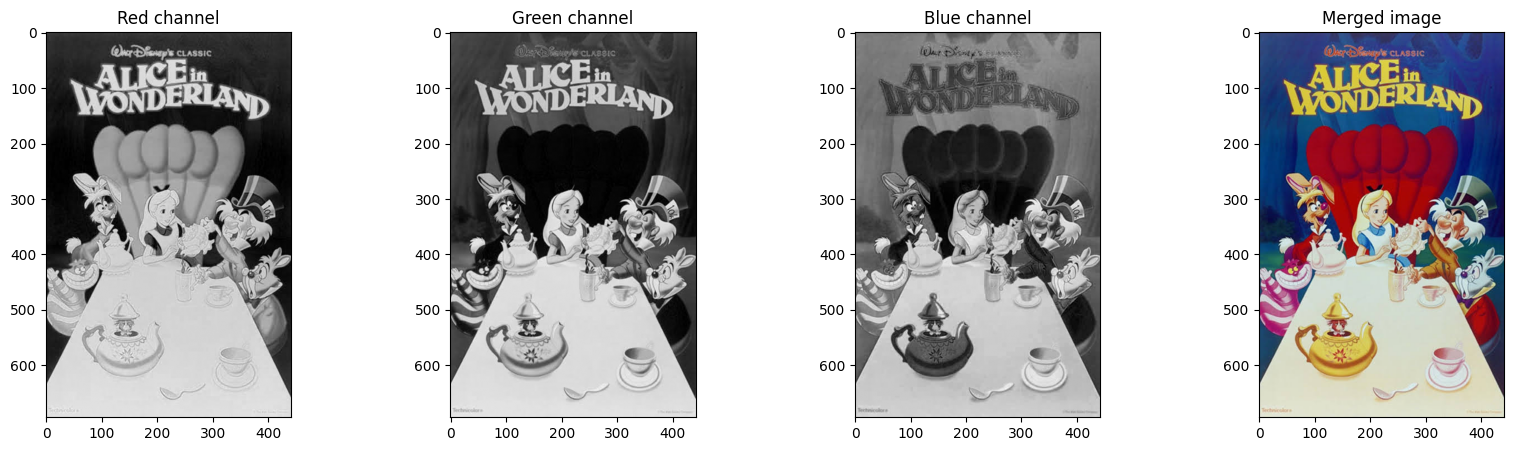

In [21]:
#Split the image into B,G,R components
alice_bgr=cv2.imread("alice_movie.jpg",cv2.IMREAD_COLOR)
b,g,r=cv2.split(alice_bgr)

#Show the channels
plt.figure(figsize=[20,5])
# 1 refers to 1 row, 4 refers to 4 columns, 1,2,3,4 refers to image positions
plt.subplot(141);plt.imshow(r,cmap="gray");plt.title("Red channel")
plt.subplot(142);plt.imshow(g,cmap="gray");plt.title("Green channel")
plt.subplot(143);plt.imshow(b,cmap="gray");plt.title("Blue channel")

#Merge the individual channels into BGR Image
alice_merge=cv2.merge((b,g,r))
#merged output
plt.subplot(144);
plt.imshow(alice_merge[:,:,::-1])
plt.title("Merged image")

Converting to different Color Spaces

cv2.cvtColor() Converts an image from one color space to another.
cv2.cvtColor( src, code )
code color space conversion code (see ColorConversionCodes : https://docs.opencv.org/4.5.1/d8/d01/group__imgproc__color__conversions.html#ga4e0972be5de079fed4e3a10e24ef5ef0 ).



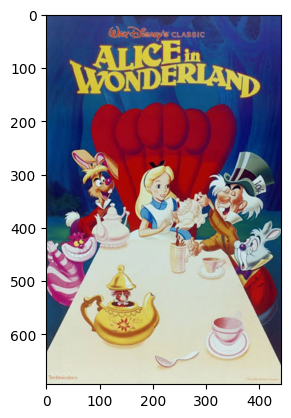

In [23]:
alice_rgb=cv2.cvtColor(alice_bgr,cv2.COLOR_BGR2RGB)
plt.imshow(alice_rgb)

Changing to HSV color space

Text(0.5, 1.0, 'Original')

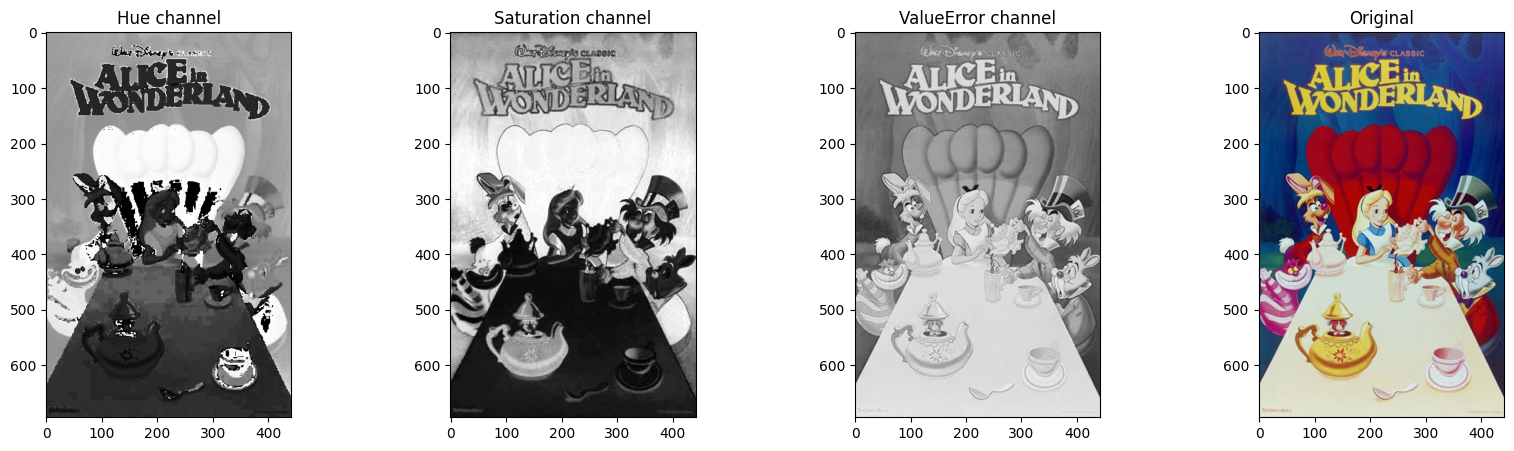

In [25]:
alice_hsv=cv2.cvtColor(alice_bgr,cv2.COLOR_BGR2HSV)

#SPLIT image into HSV channels
h,s,v=cv2.split(alice_hsv)
#show channels
plt.figure(figsize=(20,5))
plt.subplot(141);plt.imshow(h,cmap="gray");plt.title("Hue channel");
plt.subplot(142);plt.imshow(s,cmap="gray");plt.title("Saturation channel");
plt.subplot(143);plt.imshow(v,cmap="gray");plt.title("ValueError channel");
plt.subplot(144);plt.imshow(alice_rgb);plt.title("Original")


Modifying individual Channel

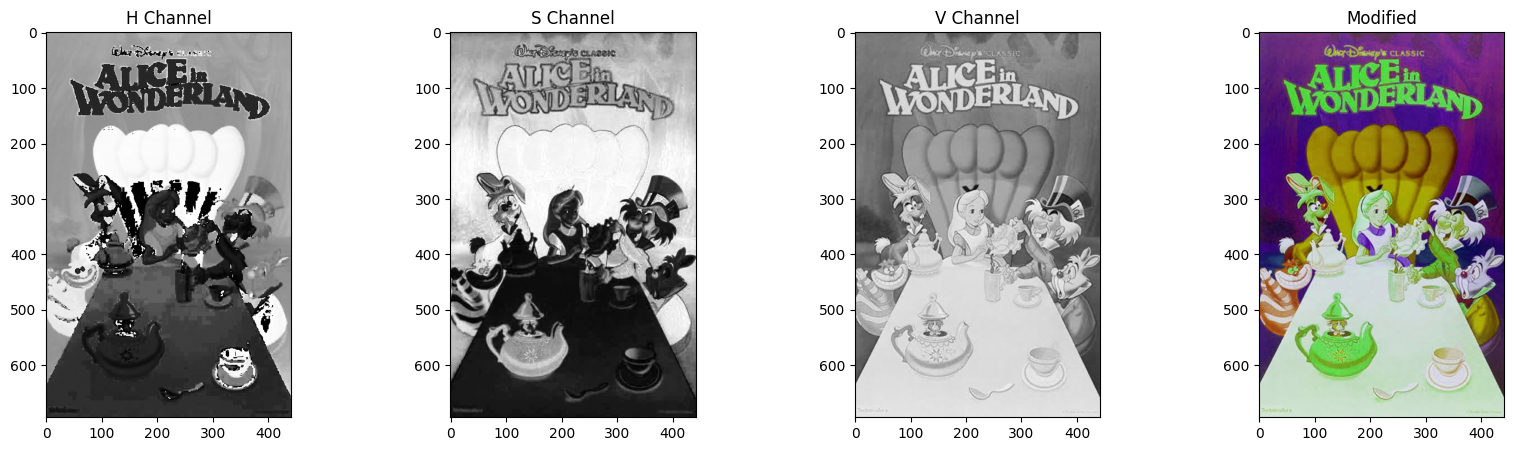

In [28]:
h_new=h+30
alice_modified=cv2.merge((h_new,s,v))
alice_new=cv2.cvtColor(alice_modified,cv2.COLOR_HSV2RGB)
# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H Channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S Channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V Channel");
plt.subplot(144);plt.imshow(alice_new);   plt.title("Modified");

Saving Images
cv2.imwrite() with two arguments
The first one is the filename, second argument is the image object

cv2.imwrite( filename, img[, params] )



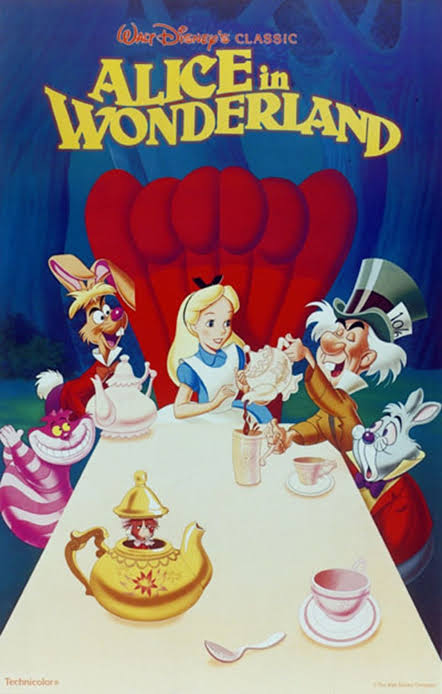

In [29]:
cv2.imwrite("alice.png",alice_bgr) #saves the image
Image("alice.png")

In [30]:
# read the image as Color
alice_bgr = cv2.imread("alice.png", cv2.IMREAD_COLOR)
print("alice_bgr shape (H, W, C) is:", alice_bgr.shape)

# read the image as Grayscaled
alice_gry = cv2.imread("alice.png", cv2.IMREAD_GRAYSCALE)
print("alice_gry shape (H, W) is:", alice_gry.shape)

alice_bgr shape (H, W, C) is: (694, 442, 3)
alice_gry shape (H, W) is: (694, 442)


# 🖼️ Exercise Summary — Getting Started with Images

## Objective

The purpose of this exercise is to understand how images are represented and processed using Python, NumPy, OpenCV, and Matplotlib.

## What I Learned

- How to read images using `cv2.imread()`
- How images are represented as NumPy arrays
- How to inspect image shape and datatype
- Difference between grayscale and color images
- How OpenCV stores color images in BGR format
- Difference between BGR and RGB
- How to split an image into individual color channels
- How to merge individual channels back into an image
- How to display images using Matplotlib
- How to convert images between different color spaces
- How to work with HSV color space
- How to modify individual image channels
- How to save processed images using `cv2.imwrite()`

## Why HSV?

HSV represents a color using:

- **H — Hue:** represents the type of color.
- **S — Saturation:** represents the intensity/purity of the color.
- **V — Value:** represents the brightness of the color.

HSV is useful in Computer Vision because color-based object detection and segmentation can often be performed more easily using Hue, Saturation, and Value ranges.

## Why is this Important?

An image is not just a picture. It is numerical data represented as pixels.

Computer Vision involves manipulating these pixel values to perform tasks such as:

- Object detection
- Image segmentation
- Color detection
- Image enhancement
- Feature extraction
- Face detection
- Medical image analysis
- Autonomous systems

This exercise helped me understand the connection between the visual appearance of an image and the numerical data stored behind it.

## Practical Experiment

I used an image from *Alice in Wonderland* and experimented with:

1. Reading the image
2. Displaying the image
3. Converting between color spaces
4. Separating image channels
5. Modifying the Hue channel
6. Observing the effect on the image
7. Saving processed images

### Key Takeaway

> **Computer Vision starts with understanding images as data.**
>
> Before learning advanced models, it is important to understand pixels, channels, color spaces, and basic image manipulation.